# Generacion automatica de dataset ML (1000 positivos / 1000 negativos)

Esta libreta construye un dataset para el clasificador de calidad fotometrica con mezcla de fuentes:

- Clase 1 (positiva): curvas reales + TESS + sinteticas con batman
- Clase 0 (negativa): estrellas estables + tránsitos destruidos + gaps + escalones instrumentales

Salida:

1. Archivos en `src/classifier/data/training/raw/` (formato CSV estandar)
2. `raw_manifest_generated.csv`
3. `manifest_training_generated.csv` y `processed/` listos para entrenamiento

In [3]:
from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd

import batman
import lightkurve as lk

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from classifier.code.prepare_dataset import (
    convert_raw_manifest_to_training_dataset,
    parse_curve_file,
)

In [6]:
# ====================== CONFIGURACION ======================
TARGET_POS = 2000
TARGET_NEG = 2000
N_POINTS_STANDARD = 260
RNG = np.random.default_rng(50)

# Interruptores de generacion para depuracion rapida
GENERATE_POSITIVES = True
GENERATE_NEGATIVES = True

RAW_DIR = PROJECT_ROOT / "src/classifier/data/test/raw"
PROCESSED_DIR = PROJECT_ROOT / "src/classifier/data/test/processed"
RAW_MANIFEST_PATH = PROJECT_ROOT / "src/classifier/data/test/raw_manifest_generated.csv"
TRAINING_MANIFEST_PATH = PROJECT_ROOT / "src/classifier/data/training/manifest_training_generated.csv"

# Ventana temporal para negativas de campo TESS (evita curvas de varios dias comprimidas).
TESS_NEG_WINDOW_HOURS: tuple[float, float] = (1.0, 2.5)

# Curvas positivas reales (ExoClock / herramienta propia)
# Nota: la busqueda es RECURSIVA (rglob), asi que puedes pasar carpeta madre
# con subcarpetas por planeta y dentro los transitos.
LOCAL_POSITIVE_DIRS: list[Path] = [
    # Path(r"C:/Users/Daniel/Desktop/En curso/Máster Astrofísica/copias_curvas/"),
    Path(r"C:/Users/Daniel/Desktop/En curso/Máster Astrofísica/TFM_datos/test/"),
]

# Curvas negativas reales (sin transito / mala calidad), opcional
# Tambien admite estructura recursiva por subcarpetas.
LOCAL_NEGATIVE_DIRS: list[Path] = [
    # Path(r"C:/ruta/a/negativas_reales"),
]

# Positivas TESS desactivadas: ya se usan las curvas del ultimo paper de ExoClock.
TESS_POSITIVE_TARGETS: list[str] = []

# Estrellas campo estables para clase negativa (editar/expandir)
TESS_FIELD_TARGETS: list[str] = [
    """
    "Tau Ceti",          # Enana G ultra-estable y cercana, el ejemplo perfecto de quietud fotométrica
    "18 Scorpii",        # El gemelo solar más perfecto conocido, sin variabilidad
    "HD 167060",         # Estrella de tipo solar en la Zona de Visión Continua de TESS (tiene decenas de sectores disponibles)
    "HD 69830",          # Enana K muy brillante y fotométricamente silenciosa
    "HD 34445",          # Estrella de tipo G vieja y muy estable
    "HD 10700",          # Otro identificador para Tau Ceti (por si acaso)
    "HD 146233",         # Otro identificador para 18 Scorpii
    "HD 219134",         # Enana K brillante, estándar de calibración fotométrica
    """
]

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print(RAW_DIR)
print(PROCESSED_DIR)

C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\src\classifier\data\test\raw
C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\src\classifier\data\test\processed


In [3]:
@dataclass
class CurveRecord:
    sample_id: str
    raw_path: str
    label: int
    source_type: str
    format_hint: str = "csv"
    flux_column: str = "detrended_flux"
    time_column: str = "time_jd"


def _standardize_curve(df: pd.DataFrame, n_points: int = N_POINTS_STANDARD) -> pd.DataFrame:
    x = np.asarray(df["time_jd"], dtype=float)
    y = np.asarray(df["detrended_flux"], dtype=float)

    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    if x.size < 20:
        raise ValueError("Curve has fewer than 20 valid points")

    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    if np.ptp(x) <= 0:
        x = np.arange(x.size, dtype=float)

    x_new = np.linspace(float(x.min()), float(x.max()), n_points)
    y_new = np.interp(x_new, x, y)

    med = float(np.median(y_new))
    if med <= 0:
        med = 1.0

    y_new = y_new / med
    return pd.DataFrame({"time_jd": x_new, "detrended_flux": y_new})


def _write_curve(df: pd.DataFrame, sample_id: str) -> Path:
    out_path = RAW_DIR / f"{sample_id}.csv"
    df.to_csv(out_path, index=False)
    return out_path


def _collect_files(dirs: Iterable[Path], suffixes: tuple[str, ...] = (".csv", ".txt", ".dat", ".tsv")) -> list[Path]:
    files: list[Path] = []
    for d in dirs:
        if not d.exists():
            continue
        for p in d.rglob("*"):
            if p.is_file() and p.suffix.lower() in suffixes:
                files.append(p)
    return files

In [4]:
def ingest_local_curves(files: list[Path], label: int, source_type: str, max_items: int) -> list[CurveRecord]:
    records: list[CurveRecord] = []
    n_ok = 0

    for path in files:
        if n_ok >= max_items:
            break

        try:
            parsed = parse_curve_file(path)
            standardized = _standardize_curve(parsed)
            sample_id = f"{source_type}_{label}_{n_ok:05d}"
            out_path = _write_curve(standardized, sample_id)
            records.append(
                CurveRecord(
                    sample_id=sample_id,
                    raw_path=str(out_path.resolve()),
                    label=label,
                    source_type=source_type,
                )
            )
            n_ok += 1
        except Exception:
            continue

    print(f"[{source_type}] curvas aceptadas: {len(records)}")
    return records


def _slice_random_time_window(df: pd.DataFrame, window_hours: tuple[float, float]) -> pd.DataFrame:
    hours_min, hours_max = window_hours
    if hours_min <= 0 or hours_max <= 0 or hours_max < hours_min:
        raise ValueError("Invalid TESS window range (hours)")

    x = np.asarray(df["time_jd"], dtype=float)
    y = np.asarray(df["detrended_flux"], dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    if x.size < 20:
        raise ValueError("Not enough points to slice time window")

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    total_span_days = float(x[-1] - x[0])
    window_days = float(RNG.uniform(hours_min / 24.0, hours_max / 24.0))

    if total_span_days <= window_days:
        return pd.DataFrame({"time_jd": x, "detrended_flux": y})

    start_min = float(x[0])
    start_max = float(x[-1] - window_days)
    start = float(RNG.uniform(start_min, start_max))
    end = start + window_days

    mask = (x >= start) & (x <= end)
    if int(np.sum(mask)) < 20:
        center = 0.5 * (start + end)
        idx = np.argsort(np.abs(x - center))[: max(20, N_POINTS_STANDARD // 2)]
        idx = np.sort(idx)
        return pd.DataFrame({"time_jd": x[idx], "detrended_flux": y[idx]})

    return pd.DataFrame({"time_jd": x[mask], "detrended_flux": y[mask]})


def _download_tess_curve(
    target: str,
    window_hours: tuple[float, float] | None = None,
) -> pd.DataFrame | None:
    try:
        sr = lk.search_lightcurve(target, mission="TESS")
        if len(sr) == 0:
            return None
        lc_collection = sr.download_all()
        if lc_collection is None or len(lc_collection) == 0:
            return None
        lc = lc_collection.stitch().remove_nans()
        lc = lc.normalize()
        lc_flat = lc.flatten(window_length=301)

        df = pd.DataFrame(
            {
                "time_jd": np.asarray(lc_flat.time.value, dtype=float),
                "detrended_flux": np.asarray(lc_flat.flux.value, dtype=float),
            }
        )

        if window_hours is not None:
            df = _slice_random_time_window(df, window_hours=window_hours)

        return _standardize_curve(df)
    except Exception:
        return None


def build_tess_records(
    targets: list[str],
    label: int,
    source_type: str,
    per_target: int,
    window_hours: tuple[float, float] | None = None,
) -> list[CurveRecord]:
    records: list[CurveRecord] = []
    k = 0
    for target in targets:
        base = _download_tess_curve(target, window_hours=window_hours)
        if base is None:
            continue

        for _ in range(per_target):
            jitter = RNG.normal(0.0, 0.0005, size=len(base))
            aug = base.copy()
            aug["detrended_flux"] = np.asarray(aug["detrended_flux"], dtype=float) + jitter
            sample_id = f"{source_type}_{label}_{k:05d}"
            out_path = _write_curve(aug, sample_id)
            records.append(
                CurveRecord(
                    sample_id=sample_id,
                    raw_path=str(out_path.resolve()),
                    label=label,
                    source_type=source_type,
                )
            )
            k += 1

    print(f"[{source_type}] curvas generadas: {len(records)}")
    return records

In [5]:
def make_batman_positive_curve(n_points: int = N_POINTS_STANDARD) -> pd.DataFrame:
    t = np.linspace(-0.08, 0.08, n_points)

    params = batman.TransitParams()
    
    # === MODIFICACIÓN 1: Aleatorizar el centro del tránsito (t0) ===
    # El tránsito ya no estará siempre en el centro exacto (0.0). 
    params.t0 = float(RNG.uniform(-0.03, 0.03))
    
    params.per = float(RNG.uniform(1.5, 6.0))
    params.rp = float(RNG.uniform(0.04, 0.16))
    params.a = float(RNG.uniform(5.5, 16.0))
    params.inc = float(RNG.uniform(84.0, 90.0))
    params.ecc = 0.0
    params.w = 90.0
    params.u = [float(RNG.uniform(0.15, 0.55)), float(RNG.uniform(0.05, 0.35))]
    params.limb_dark = "quadratic"

    model = batman.TransitModel(params, t)
    flux = model.light_curve(params)

    white_sigma = float(RNG.uniform(3e-4, 2.5e-3))
    white = RNG.normal(0.0, white_sigma, size=n_points)

    phi = float(RNG.uniform(0.2, 0.85))
    red_sigma = float(RNG.uniform(2e-4, 1.2e-3))
    red = np.zeros(n_points, dtype=float)
    eps = RNG.normal(0.0, red_sigma, size=n_points)
    for i in range(1, n_points):
        red[i] = phi * red[i - 1] + eps[i]

    trend = np.polyval([float(RNG.uniform(-0.03, 0.03)), float(RNG.uniform(-0.004, 0.004)), 1.0], np.linspace(-1.0, 1.0, n_points))

    y = flux * trend + white + red
    y = y / np.median(y)

    # Devolvemos la fecha base unificada 2450000.0
    return pd.DataFrame({"time_jd": 2450000.0 + t, "detrended_flux": y})


def destroy_transit_with_noise(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    sigma = float(RNG.uniform(0.008, 0.03))
    out["detrended_flux"] = np.asarray(out["detrended_flux"], dtype=float) + RNG.normal(0.0, sigma, size=len(out))
    out["detrended_flux"] = np.asarray(out["detrended_flux"], dtype=float) / np.median(out["detrended_flux"])
    return out


def add_critical_gap(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    y = np.asarray(out["detrended_flux"], dtype=float)
    idx = int(np.argmin(y))
    w = int(RNG.integers(12, 26))
    mask = np.ones(len(out), dtype=bool)
    mask[max(0, idx - w) : min(len(out), idx + w + 1)] = False
    out = out.loc[mask].reset_index(drop=True)
    return _standardize_curve(out)


def add_instrument_step(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    y = np.asarray(out["detrended_flux"], dtype=float).copy()
    k = int(RNG.integers(len(y) // 4, 3 * len(y) // 4))
    step = float(RNG.uniform(-0.02, 0.02))
    y[k:] += step
    y += RNG.normal(0.0, float(RNG.uniform(6e-4, 2e-3)), size=len(y))
    y = y / np.median(y)
    out["detrended_flux"] = y
    return out

def make_synthetic_negative_baseline(n_points: int = N_POINTS_STANDARD) -> pd.DataFrame:
    # === MODIFICACIÓN 2: Unificar el eje temporal con las positivas ===
    # Forzamos a que la curva mala dure exactamente lo mismo (0.16 días)
    # y tenga la misma escala temporal para que slope_linear no sufra distorsión.
    t = np.linspace(-0.08, 0.08, n_points)
    
    phi = float(RNG.uniform(0.3, 0.9))
    sigma = float(RNG.uniform(8e-4, 4e-3))
    red = np.zeros(n_points, dtype=float)
    eps = RNG.normal(0.0, sigma, size=n_points)
    for i in range(1, n_points):
        red[i] = phi * red[i - 1] + eps[i]
        
    trend = 1.0 + np.polyval([float(RNG.uniform(-0.08, 0.08)), float(RNG.uniform(-0.02, 0.02)), 0.0], np.linspace(-1.0, 1.0, n_points))
    y = trend + red
    y = y / np.median(y)
    
    # Devolvemos la fecha base unificada 2450000.0
    return pd.DataFrame({"time_jd": 2450000.0 + t, "detrended_flux": y})

In [6]:
records: list[CurveRecord] = []
positive_curves_for_augmentation: list[pd.DataFrame] = []

if GENERATE_POSITIVES:
    # Diagnostico rapido de rutas positivas locales
    for d in LOCAL_POSITIVE_DIRS:
        print(f"[local_pos_dir] {d} | exists={d.exists()}")

    # 1) Positivas locales reales
    pos_local_files = _collect_files(LOCAL_POSITIVE_DIRS)
    print(f"[local_pos] archivos candidatos encontrados: {len(pos_local_files)}")
    pos_local = ingest_local_curves(pos_local_files, label=1, source_type="local_pos", max_items=2000)
    records.extend(pos_local)

    if len(pos_local) == 0:
        raise RuntimeError(
            "No se pudo cargar ninguna curva positiva local. Revisa rutas y formatos de archivo. "
            "No se rellena con batman para evitar dataset sesgado por error silencioso."
        )

    for rec in pos_local:
        positive_curves_for_augmentation.append(pd.read_csv(rec.raw_path))

    # 2) Positivas TESS (desactivadas por configuracion: lista vacia)
    pos_tess = build_tess_records(TESS_POSITIVE_TARGETS, label=1, source_type="tess_pos", per_target=0, window_hours=None)
    records.extend(pos_tess)
    for rec in pos_tess:
        positive_curves_for_augmentation.append(pd.read_csv(rec.raw_path))

    # 3) Positivas sinteticas batman hasta TARGET_POS
    n_pos = sum(r.label == 1 for r in records)
    k = 0
    while n_pos < TARGET_POS:
        df = make_batman_positive_curve()
        sample_id = f"batman_pos_1_{k:05d}"
        out_path = _write_curve(df, sample_id)
        records.append(CurveRecord(sample_id=sample_id, raw_path=str(out_path.resolve()), label=1, source_type="batman_pos"))
        positive_curves_for_augmentation.append(df)
        n_pos += 1
        k += 1

    print(f"Clase positiva final: {n_pos}")
else:
    print("Generacion de positivas desactivada (GENERATE_POSITIVES=False)")

if GENERATE_NEGATIVES:
    # 4) Negativas locales reales
    neg_local_files = _collect_files(LOCAL_NEGATIVE_DIRS)
    neg_local = ingest_local_curves(neg_local_files, label=0, source_type="local_neg", max_items=2000)
    records.extend(neg_local)

    # 5) Negativas TESS campo estable
    neg_tess = build_tess_records(TESS_FIELD_TARGETS, label=0, source_type="tess_field_neg", per_target=0, window_hours=TESS_NEG_WINDOW_HOURS)
    records.extend(neg_tess)

    # 6) Negativas sinteticas (destruccion/noise/gaps/steps)
    n_neg = sum(r.label == 0 for r in records)
    k = 0
    while n_neg < TARGET_NEG:
        mode = int(RNG.integers(0, 4))

        if mode == 0 and positive_curves_for_augmentation:
            base = positive_curves_for_augmentation[int(RNG.integers(0, len(positive_curves_for_augmentation)))].copy()
            df = destroy_transit_with_noise(base)
            source = "neg_noise_destroyed"
        elif mode == 1 and positive_curves_for_augmentation:
            base = positive_curves_for_augmentation[int(RNG.integers(0, len(positive_curves_for_augmentation)))].copy()
            df = add_critical_gap(base)
            source = "neg_critical_gap"
        elif mode == 2 and positive_curves_for_augmentation:
            base = positive_curves_for_augmentation[int(RNG.integers(0, len(positive_curves_for_augmentation)))].copy()
            df = add_instrument_step(base)
            source = "neg_instrument_step"
        else:
            df = make_synthetic_negative_baseline()
            source = "neg_baseline"

        sample_id = f"{source}_0_{k:05d}"
        out_path = _write_curve(df, sample_id)
        records.append(CurveRecord(sample_id=sample_id, raw_path=str(out_path.resolve()), label=0, source_type=source))
        n_neg += 1
        k += 1

    print(f"Clase negativa final: {n_neg}")
else:
    print("Generacion de negativas desactivada (GENERATE_NEGATIVES=False)")

[local_pos_dir] C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM_datos\test | exists=True
[local_pos] archivos candidatos encontrados: 514
[local_pos] curvas aceptadas: 487
[tess_pos] curvas generadas: 0
Clase positiva final: 2000
[local_neg] curvas aceptadas: 0


Could not resolve "
    "Tau Ceti",          # Enana G ultra-estable y cercana, el ejemplo perfecto de quietud fotométrica
    "18 Scorpii",        # El gemelo solar más perfecto conocido, sin variabilidad
    "HD 167060",         # Estrella de tipo solar en la Zona de Visión Continua de TESS (tiene decenas de sectores disponibles)
    "HD 69830",          # Enana K muy brillante y fotométricamente silenciosa
    "HD 34445",          # Estrella de tipo G vieja y muy estable
    "HD 10700",          # Otro identificador para Tau Ceti (por si acaso)
    "HD 146233",         # Otro identificador para 18 Scorpii
    "HD 219134",         # Enana K brillante, estándar de calibración fotométrica
    " to a sky position.


[tess_field_neg] curvas generadas: 0
Clase negativa final: 2000


In [7]:
raw_manifest_df = pd.DataFrame([r.__dict__ for r in records])
raw_manifest_df = raw_manifest_df.sort_values(["label", "source_type", "sample_id"]).reset_index(drop=True)
raw_manifest_df.to_csv(RAW_MANIFEST_PATH, index=False)

print("Raw manifest:", RAW_MANIFEST_PATH)
print(raw_manifest_df["label"].value_counts().sort_index())
print(raw_manifest_df["source_type"].value_counts().head(12))

Raw manifest: C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\src\classifier\data\test\raw_manifest_generated.csv
label
0    2000
1    2000
Name: count, dtype: int64
source_type
batman_pos             1513
neg_baseline            507
neg_critical_gap        504
neg_instrument_step     498
neg_noise_destroyed     491
local_pos               487
Name: count, dtype: int64


In [16]:
# Conversion raw -> processed + training manifest
training_manifest_df = convert_raw_manifest_to_training_dataset(
    raw_manifest_path=RAW_MANIFEST_PATH,
    processed_dir=PROCESSED_DIR,
    output_manifest_path=TRAINING_MANIFEST_PATH,
)

print("Training manifest:", TRAINING_MANIFEST_PATH)
print(training_manifest_df["label"].value_counts().sort_index())
training_manifest_df.head()

Training manifest: C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\src\classifier\data\training\manifest_training_generated.csv
label
0    15000
1    13319
Name: count, dtype: int64


,sample_id,label,source_type,curve_path
0,neg_baseline_0_00009,0,neg_baseline,C:\Users\Daniel\Desktop\En curso\Máster Astrof...
1,neg_baseline_0_00011,0,neg_baseline,C:\Users\Daniel\Desktop\En curso\Máster Astrof...
2,neg_baseline_0_00016,0,neg_baseline,C:\Users\Daniel\Desktop\En curso\Máster Astrof...
3,neg_baseline_0_00017,0,neg_baseline,C:\Users\Daniel\Desktop\En curso\Máster Astrof...
4,neg_baseline_0_00018,0,neg_baseline,C:\Users\Daniel\Desktop\En curso\Máster Astrof...


## Entrenamiento del clasificador

Cuando ya tengas `manifest_training_generated.csv`, puedes entrenar el modelo RF:

```bash
D:/anaconda3/python.exe -m classifier.code.train --manifest src/classifier/data/training/manifest_training_generated.csv --output-dir src/classifier/artifacts --flux-column detrended_flux --time-column time_jd
```

Notas:

- Si no hay internet, la parte de TESS puede devolver 0 curvas; el bloque seguira con locales + sinteticas.
- Puedes subir/bajar el peso de cada fuente cambiando `max_items` y `per_target`.
- Revisa visualmente una muestra de curvas para asegurar calidad de etiquetas.

## Revision aleatoria rapida (10 positivas + 10 negativas)

Este bloque toma una muestra aleatoria balanceada desde `manifest_training_generated.csv` y muestra 20 curvas para inspeccion visual.

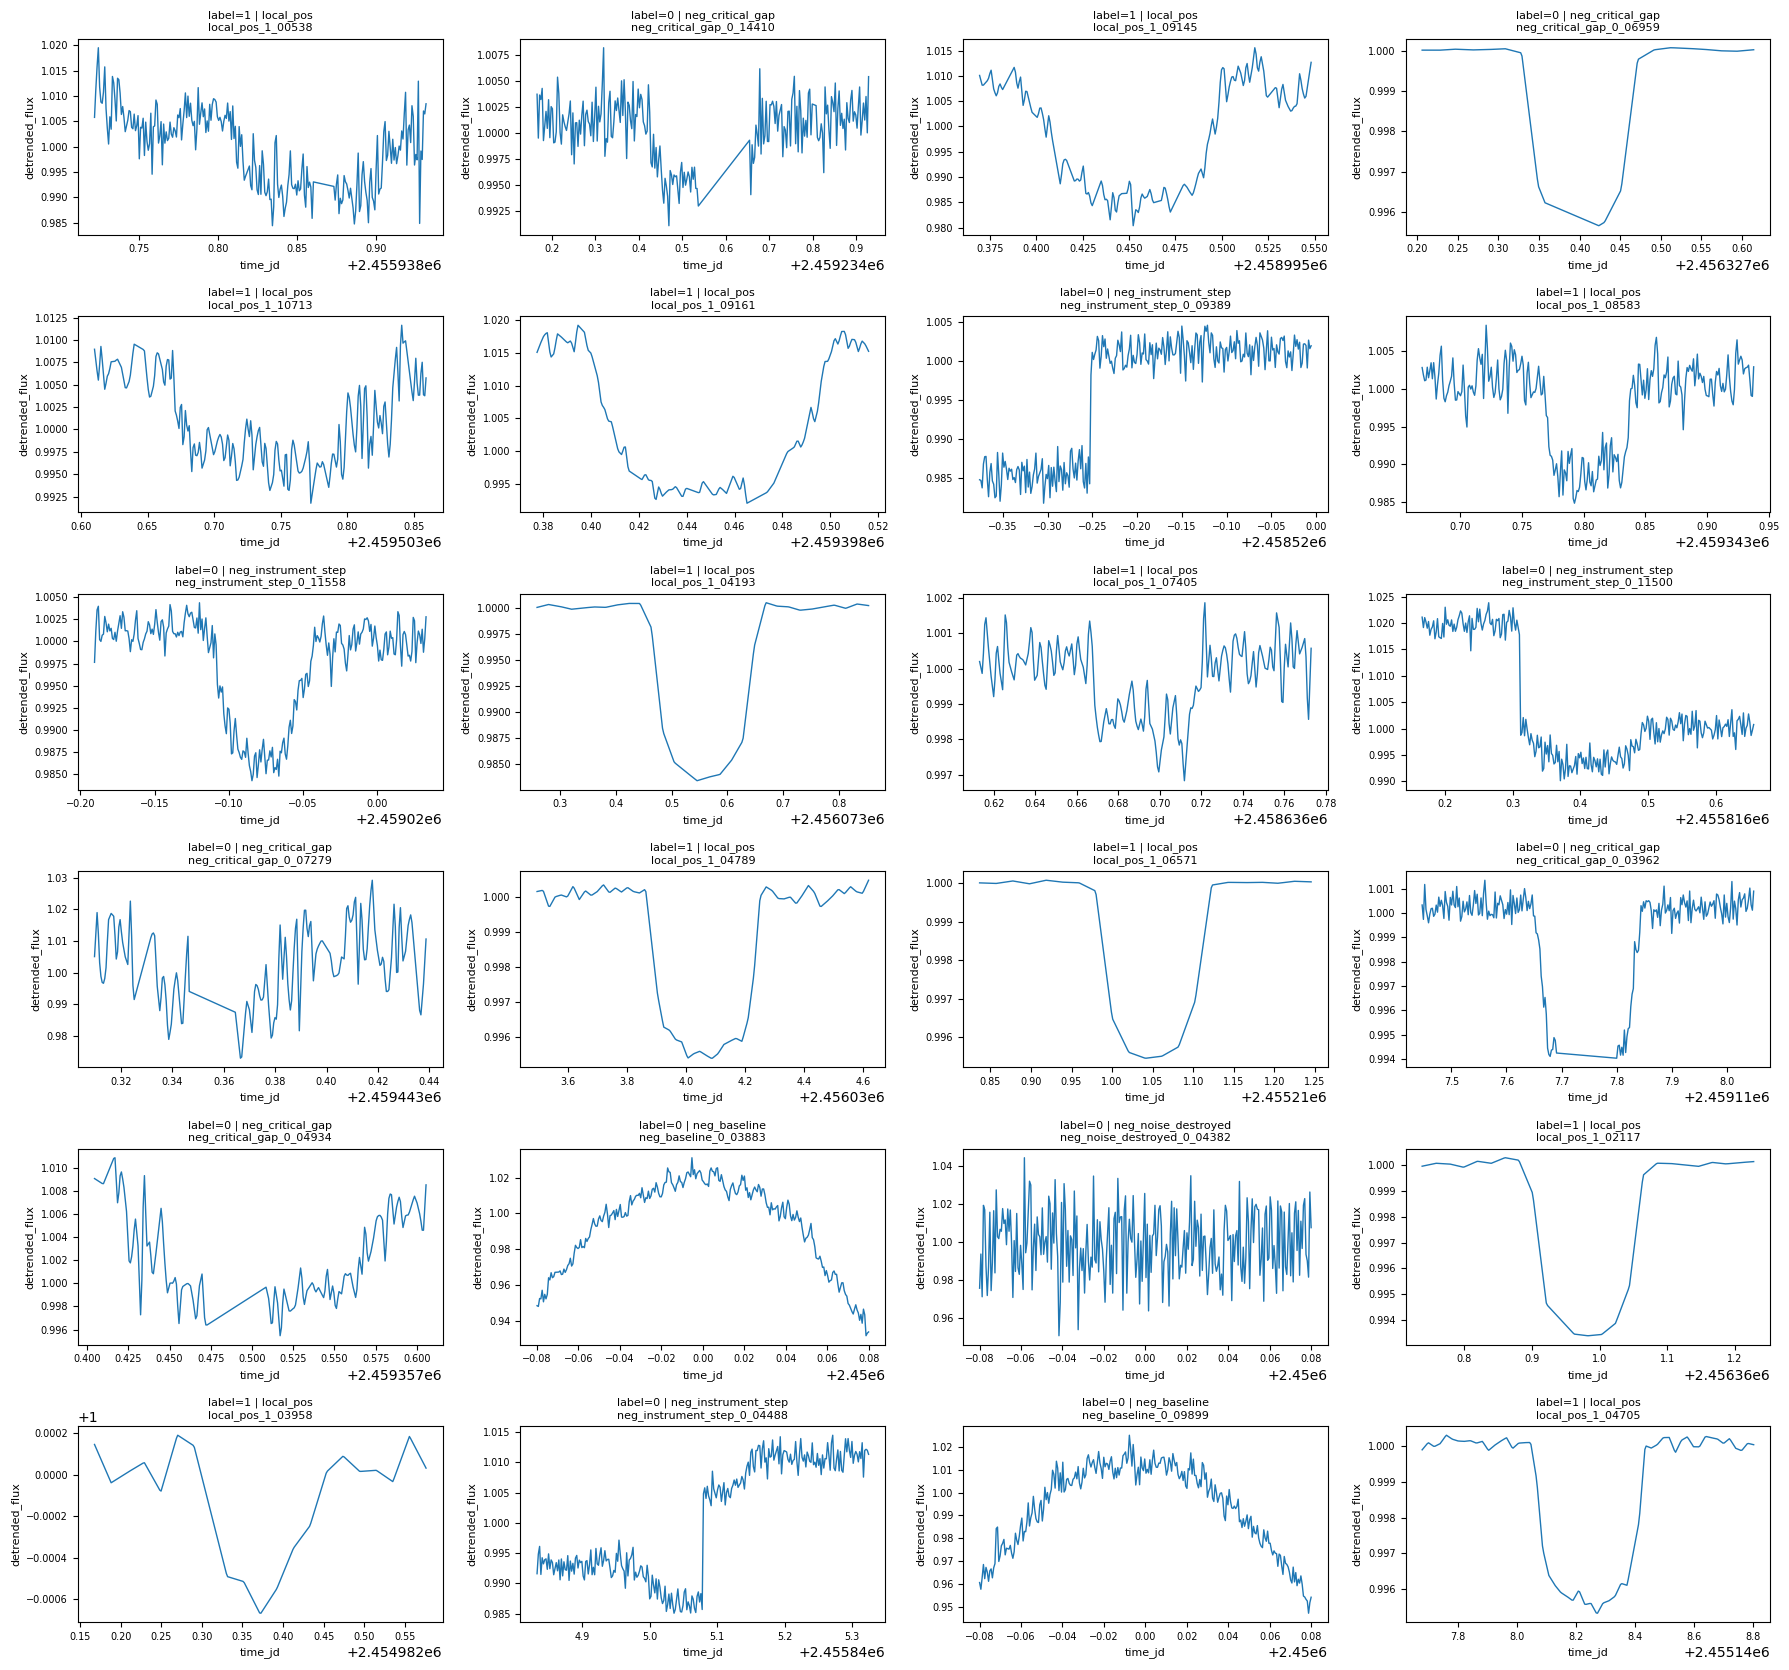

Resumen de la muestra de revision:
label
0    12
1    12
Name: count, dtype: int64


,sample_id,label,source_type,curve_path
0,local_pos_1_00538,1,local_pos,C:\Users\Daniel\Desktop\En curso\Máster Astrof...
1,neg_critical_gap_0_14410,0,neg_critical_gap,C:\Users\Daniel\Desktop\En curso\Máster Astrof...
2,local_pos_1_09145,1,local_pos,C:\Users\Daniel\Desktop\En curso\Máster Astrof...
3,neg_critical_gap_0_06959,0,neg_critical_gap,C:\Users\Daniel\Desktop\En curso\Máster Astrof...
4,local_pos_1_10713,1,local_pos,C:\Users\Daniel\Desktop\En curso\Máster Astrof...
5,local_pos_1_09161,1,local_pos,C:\Users\Daniel\Desktop\En curso\Máster Astrof...
6,neg_instrument_step_0_09389,0,neg_instrument_step,C:\Users\Daniel\Desktop\En curso\Máster Astrof...
7,local_pos_1_08583,1,local_pos,C:\Users\Daniel\Desktop\En curso\Máster Astrof...
8,neg_instrument_step_0_11558,0,neg_instrument_step,C:\Users\Daniel\Desktop\En curso\Máster Astrof...
9,local_pos_1_04193,1,local_pos,C:\Users\Daniel\Desktop\En curso\Máster Astrof...


In [9]:
import matplotlib.pyplot as plt

REVIEW_PER_CLASS = 12

if not TRAINING_MANIFEST_PATH.exists():
    raise FileNotFoundError(f"No existe el manifest de entrenamiento: {TRAINING_MANIFEST_PATH}")

review_df = pd.read_csv(TRAINING_MANIFEST_PATH)

required_cols = {"curve_path", "label", "sample_id", "source_type"}
missing_cols = required_cols.difference(review_df.columns)
if missing_cols:
    raise ValueError(f"Faltan columnas en el manifest: {sorted(missing_cols)}")

sampled_parts: list[pd.DataFrame] = []
for label_value in (1, 0):
    subset = review_df.loc[review_df["label"] == label_value].copy()
    if subset.empty:
        print(f"No hay muestras para label={label_value}; se omite.")
        continue
    n_take = min(REVIEW_PER_CLASS, len(subset))
    sampled_parts.append(subset.sample(n=n_take, random_state=42))

if not sampled_parts:
    raise RuntimeError("No hay muestras para revisar en el manifest.")

review_sample = pd.concat(sampled_parts, axis=0).reset_index(drop=True)
review_sample = review_sample.sample(frac=1.0, random_state=42).reset_index(drop=True)

n = len(review_sample)
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 2.8 * rows), squeeze=False)
axes_flat = axes.flatten()

for i, row in review_sample.iterrows():
    ax = axes_flat[i]
    curve_path = Path(str(row["curve_path"]))

    try:
        cdf = pd.read_csv(curve_path)
        x = np.asarray(cdf["time_jd"], dtype=float)
        y = np.asarray(cdf["detrended_flux"], dtype=float)
        ax.plot(x, y, lw=1.0)
        ax.set_title(
            f"label={int(row['label'])} | {row['source_type']}\n{row['sample_id']}",
            fontsize=8,
        )
        ax.set_xlabel("time_jd", fontsize=8)
        ax.set_ylabel("detrended_flux", fontsize=8)
        ax.tick_params(labelsize=7)
    except Exception as exc:
        ax.text(0.5, 0.5, f"Error al leer curva\n{curve_path.name}\n{exc}", ha="center", va="center", fontsize=8)
        ax.set_title(f"label={int(row['label'])} | {row['source_type']}", fontsize=8)
        ax.set_axis_off()

for j in range(n, len(axes_flat)):
    axes_flat[j].set_axis_off()

plt.tight_layout()
plt.show()

print("Resumen de la muestra de revision:")
print(review_sample["label"].value_counts().sort_index())
review_sample[["sample_id", "label", "source_type", "curve_path"]].head(20)